# Actor-Critic Fundamentals

            ## 1. Learning objectives

            - Separate policy and value roles
- Use TD error as an advantage estimate
- Train actor and critic together

            ## 2. Prerequisites

            Python loops, NumPy arrays, probability, expected value, and basic supervised-learning vocabulary.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


def plot_rl_metrics(rewards, exploration_rates, episode_lengths, title):
    rewards = np.asarray(rewards, dtype=float)
    window = min(20, len(rewards))
    moving = np.convolve(rewards, np.ones(window)/window, mode="valid")
    episodes = np.arange(1, len(rewards)+1)
    figure, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    axes[0].plot(episodes, rewards, alpha=.35, color=COURSE_COLORS["blue"], label="Episode reward")
    axes[0].plot(episodes[window-1:], moving, color=COURSE_COLORS["orange"], label=f"{window}-episode average")
    axes[0].set(title=title, ylabel="Reward"); axes[0].legend()
    axes[1].plot(episodes, exploration_rates, color=COURSE_COLORS["olive"])
    axes[1].set(ylabel="Exploration rate")
    axes[2].plot(episodes, episode_lengths, color=COURSE_COLORS["pink"])
    axes[2].set(xlabel="Episode", ylabel="Episode length")
    figure.tight_layout()
    plt.show()

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Reduce policy-gradient variance by learning a baseline that evaluates states.

            ## 4. Real-world use cases

            - Adaptive control
- Resource allocation
- Sequential recommendation experiments

            ## 5. Core intuition in simple language

            The actor chooses; the critic judges whether the outcome was better or worse than expected; that surprise trains both.

## 6. Mathematical foundation

            $$\delta_t=R_{t+1}+\gamma V_\phi(S_{t+1})-V_\phi(S_t).$$

            **Every symbol:**

            - $\delta_t$ is TD error and advantage estimate.
- $R_{t+1}$ is reward.
- $\gamma$ discounts.
- $V_\phi$ is critic value with parameters phi.
- $S_t,S_{t+1}$ are states.

            **Why the equation is needed:** Subtracting expected value centers policy updates and trains the critic toward a one-step target.

            **Small numerical example:** For reward .8, gamma=.9, next value .6, current value .5, delta=.8+.54-.5=.84.

            **Connection to Python:** advantage = reward + gamma*next_value - value drives actor log-probability and critic squared-error losses.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Reset the environment
2. Observe state
3. Choose an action from the policy
4. Receive next state and reward
5. Update values or policy
6. Repeat until termination and across episodes

## 9. Implementation from scratch

A tiny custom environment keeps states, actions, rewards, and transitions visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
reward=.8
value=.5
next_value=.6
gamma=.9
td_error=reward+gamma*next_value-value
print("One-step advantage estimate:",td_error)

One-step advantage estimate: 0.8400000000000001


## 10. Implementation using a standard library

NumPy handles tabular methods; PyTorch is introduced only for value or policy function approximation.

## 11. Dataset loading and exploration

Reinforcement learning generates experience through environment interaction rather than loading labeled rows.

## 12. Data preprocessing

Discrete states are indexed directly; neural agents convert states to normalized float tensors.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Actor/critic parameters: 146 129
Actor output shape: (6, 2) critic output shape: (6, 1)


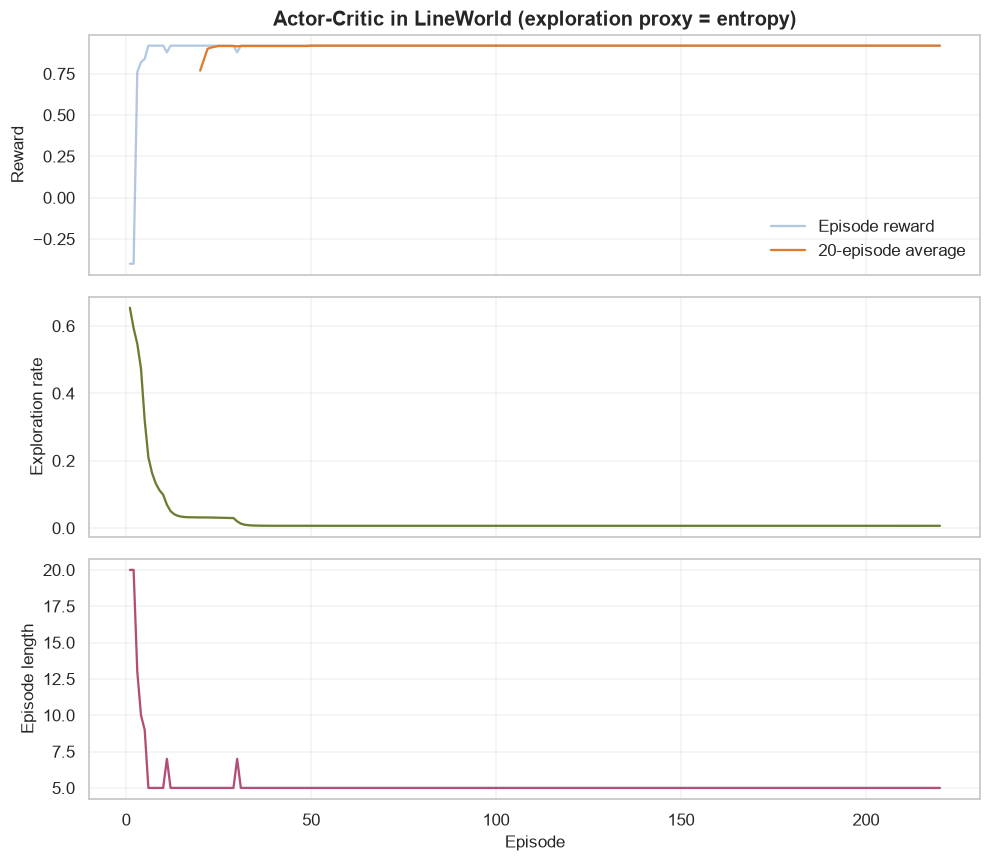

In [3]:
class LineWorld:
    def __init__(self, length=6, max_steps=20):
        self.length=length
        self.max_steps=max_steps
    def reset(self):
        self.state=0
        self.steps=0
        return self.state
    def step(self, action):
        self.steps+=1
        self.state=int(np.clip(self.state + (-1 if action==0 else 1),0,self.length-1))
        terminated=self.state==self.length-1
        truncated=self.steps>=self.max_steps
        reward=1.0 if terminated else -0.02
        return self.state,reward,terminated,truncated

import torch
from torch import nn
torch.set_num_threads(1)
environment=LineWorld()
actor=nn.Sequential(nn.Linear(environment.length,16),nn.Tanh(),nn.Linear(16,2))
critic=nn.Sequential(nn.Linear(environment.length,16),nn.Tanh(),nn.Linear(16,1))
optimizer=torch.optim.Adam(list(actor.parameters())+list(critic.parameters()),lr=.01)
rewards=[]; exploration_rates=[]; lengths=[]
def encode(state):
    result=torch.zeros(environment.length); result[state]=1; return result
for episode in range(220):
    state=environment.reset(); total=0.0; entropies=[]
    for step in range(environment.max_steps):
        state_tensor=encode(state)
        distribution=torch.distributions.Categorical(logits=actor(state_tensor))
        action=distribution.sample()
        next_state,reward,terminated,truncated=environment.step(int(action))
        value=critic(state_tensor).squeeze()
        with torch.no_grad(): next_value=torch.tensor(0.) if terminated else critic(encode(next_state)).squeeze()
        advantage=torch.tensor(reward)+.95*next_value-value
        actor_loss=-distribution.log_prob(action)*advantage.detach()
        critic_loss=advantage.pow(2)
        loss=actor_loss+.5*critic_loss
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        entropies.append(float(distribution.entropy().detach()))
        state=next_state; total+=reward
        if terminated or truncated: break
    rewards.append(total); exploration_rates.append(float(np.mean(entropies))); lengths.append(step+1)
print("Actor/critic parameters:",sum(p.numel() for p in actor.parameters()),sum(p.numel() for p in critic.parameters()))
print("Actor output shape:",tuple(actor(torch.eye(environment.length)).shape),"critic output shape:",tuple(critic(torch.eye(environment.length)).shape))
plot_rl_metrics(rewards,exploration_rates,lengths,"Actor-Critic in LineWorld (exploration proxy = entropy)")

**How to interpret the result:** Reward increases and episode length falls as the actor learns rightward actions; entropy decreases as the policy becomes more certain.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

An entropy bonus can preserve exploration, but too much prevents the policy from becoming decisive.

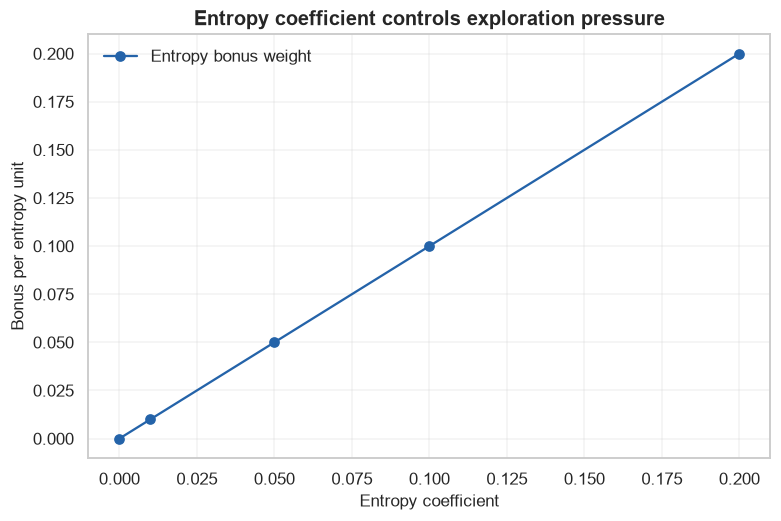

In [4]:
coefficients=[0,.01,.05,.1,.2]
figure,axis=plt.subplots(); axis.plot(coefficients,coefficients,marker="o",color=COURSE_COLORS["blue"],label="Entropy bonus weight")
axis.set(title="Entropy coefficient controls exploration pressure",xlabel="Entropy coefficient",ylabel="Bonus per entropy unit"); axis.legend(); plt.show()

## 18. Common mistakes

            - Treating reward as a supervised label
- Evaluating while exploration is still active
- Comparing agents with different random seeds or episode limits
- Ignoring truncation versus true termination

            ## 19. Advantages and disadvantages

            **Advantages**

            - Directly optimizes sequential behavior
- Can learn from interaction without action labels

            **Disadvantages**

            - Experience can be expensive or unsafe
- Results are noisy and sensitive to reward design

            ## 20. When to use and when not to use the algorithm

            **Use it when:** actions influence future states and the objective is naturally expressed through cumulative reward.

            **Do not use it when:** a static labeled prediction problem is sufficient or unsafe exploration cannot be controlled.

## 21. Exercises

1. **Conceptual:** Why is RL not supervised learning?
2. **Mathematical/hand calculation:** Calculate return for rewards [2,0,4] with gamma=.5.
3. **Coding/experimentation:** Change one hyperparameter and compare learning across at least three seeds.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. The agent is not given correct actions; it receives consequences and must handle delayed credit.
2. 2+.5(0)+.25(4)=3.
3. Keep all other settings fixed, plot each seed plus aggregate mean, and avoid selecting only the best run.

</details>

## 23. Summary and key takeaways

            - The policy maps states to action choices
- Return assigns credit across time
- Exploration gathers information while exploitation uses current knowledge
- Learning curves require repeated, controlled evaluation

            ## 24. Further reading

            - [Gymnasium documentation](https://gymnasium.farama.org/)
- [Sutton and Barto: Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)